## NIVEL EXPLORADOR – VISUALIZACIÓN DE DATOS ##


Creacion del NoteBook e importancion de librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap
import datetime as dt
import plotly.express as px
import matplotlib.ticker as ticker

Cargar el dataset

In [ ]:

df = pd.read_csv("retail_store_inventory.csv")

In [ ]:
# mostrar las primeras 5 filas
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer


In [4]:
# Verificar el número de registros y columnas
print(f"Registros: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")


Registros: 73100
Columnas: 15


In [8]:
# Mostrar solo las columnas con valores nulos
df.isnull().sum()[df.isnull().sum() > 0]


Series([], dtype: int64)

In [11]:
# descripcion del dataset
df.describe(include="all")

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
count,73100,73100,73100,73100,73100,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100.000000,73100,73100.000000,73100.000000,73100
unique,731,5,20,5,4,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,4
top,2022-01-01,S001,P0001,Furniture,East,NaN,NaN,NaN,NaN,NaN,NaN,Sunny,NaN,NaN,Spring
freq,100,14620,3655,14699,18349,NaN,NaN,NaN,NaN,NaN,NaN,18290,NaN,NaN,18317
mean,NaN,NaN,NaN,NaN,NaN,274.469877,136.464870,110.004473,141.494720,55.135108,10.009508,NaN,0.497305,55.146077,NaN
std,NaN,NaN,NaN,NaN,NaN,129.949514,108.919406,52.277448,109.254076,26.021945,7.083746,NaN,0.499996,26.191408,NaN
min,NaN,NaN,NaN,NaN,NaN,50.000000,0.000000,20.000000,-9.990000,10.000000,0.000000,NaN,0.000000,5.030000,NaN
25%,NaN,NaN,NaN,NaN,NaN,162.000000,49.000000,65.000000,53.670000,32.650000,5.000000,NaN,0.000000,32.680000,NaN
50%,NaN,NaN,NaN,NaN,NaN,273.000000,107.000000,110.000000,113.015000,55.050000,10.000000,NaN,0.000000,55.010000,NaN
75%,NaN,NaN,NaN,NaN,NaN,387.000000,203.000000,155.000000,208.052500,77.860000,15.000000,NaN,1.000000,77.820000,NaN


In [13]:
#nombres de las columnas
df.columns

Index(['Date', 'Store ID', 'Product ID', 'Category', 'Region',
       'Inventory Level', 'Units Sold', 'Units Ordered', 'Demand Forecast',
       'Price', 'Discount', 'Weather Condition', 'Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'],
      dtype='object')

In [14]:
# Convertir columna Fecha
df["Date"] = pd.to_datetime(df["Date"])

In [15]:
df

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Demand Forecast,Price,Discount,Weather Condition,Holiday/Promotion,Competitor Pricing,Seasonality
0,2022-01-01,S001,P0001,Groceries,North,231,127,55,135.47,33.50,20,Rainy,0,29.69,Autumn
1,2022-01-01,S001,P0002,Toys,South,204,150,66,144.04,63.01,20,Sunny,0,66.16,Autumn
2,2022-01-01,S001,P0003,Toys,West,102,65,51,74.02,27.99,10,Sunny,1,31.32,Summer
3,2022-01-01,S001,P0004,Toys,North,469,61,164,62.18,32.72,10,Cloudy,1,34.74,Autumn
4,2022-01-01,S001,P0005,Electronics,East,166,14,135,9.26,73.64,0,Sunny,0,68.95,Summer
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73095,2024-01-01,S005,P0016,Furniture,East,96,8,127,18.46,73.73,20,Snowy,0,72.45,Winter
73096,2024-01-01,S005,P0017,Toys,North,313,51,101,48.43,82.57,10,Cloudy,0,83.78,Autumn
73097,2024-01-01,S005,P0018,Clothing,West,278,36,151,39.65,11.11,10,Rainy,0,10.91,Winter
73098,2024-01-01,S005,P0019,Toys,East,374,264,21,270.52,53.14,20,Rainy,0,55.80,Spring


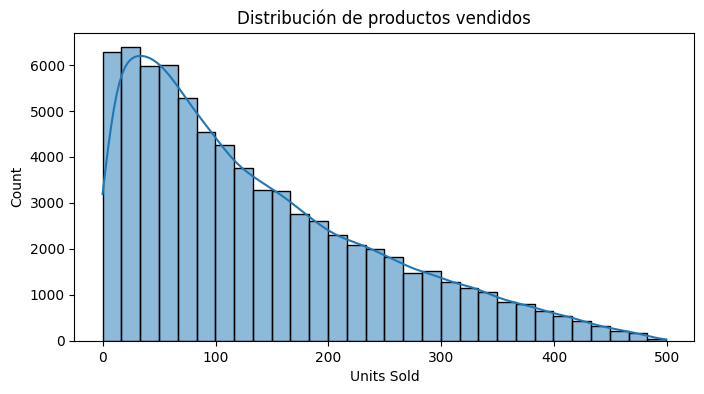

In [16]:
# Histograma de productos vendidos
plt.figure(figsize=(8,4))
sns.histplot(df["Units Sold"], bins=30, kde=True)
plt.title("Distribución de productos vendidos")
plt.show()

C:\Users\miass\AppData\Local\Temp\ipykernel_1156\4014423291.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="Category")


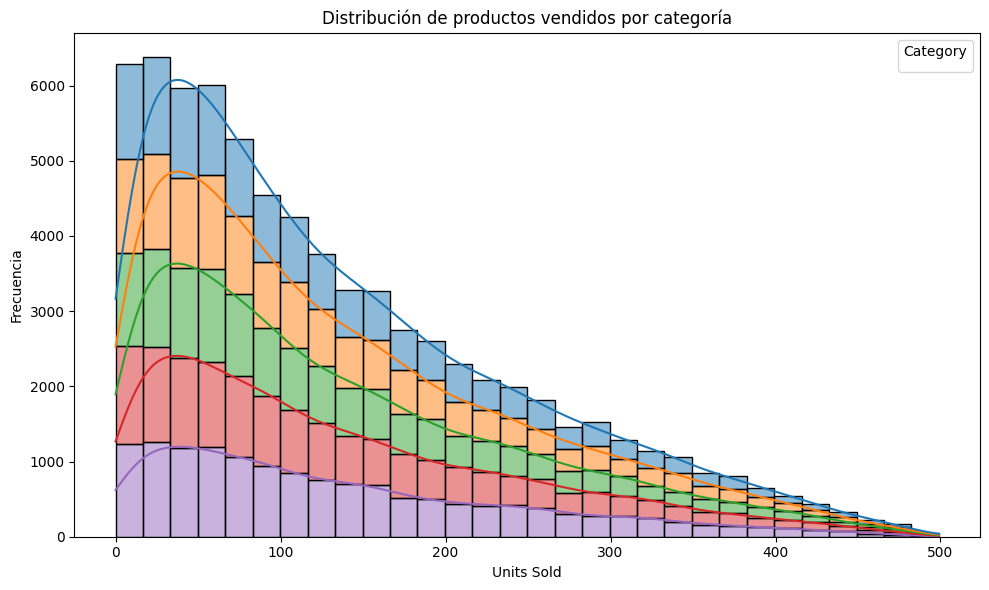

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x="Units Sold", hue="Category", bins=30, kde=True, multiple="stack")
plt.title("Distribución de productos vendidos por categoría")
plt.xlabel("Units Sold")
plt.ylabel("Frecuencia")
plt.legend(title="Category")
plt.tight_layout()
plt.show()


C:\Users\miass\AppData\Local\Temp\ipykernel_1156\3358855106.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventas_por_categoria.values, y=ventas_por_categoria.index, palette="viridis")


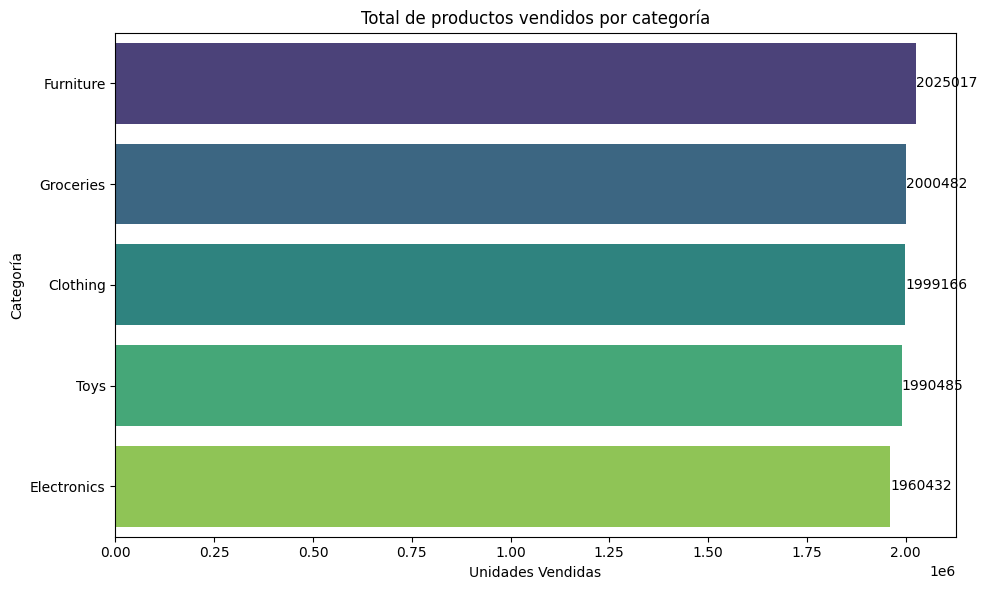

In [18]:
# Agrupar por categoría y sumar unidades vendidas
ventas_por_categoria = df.groupby("Category")["Units Sold"].sum().sort_values(ascending=False)

# Crear gráfico
plt.figure(figsize=(10, 6))
sns.barplot(x=ventas_por_categoria.values, y=ventas_por_categoria.index, palette="viridis")

# Etiquetas
plt.title("Total de productos vendidos por categoría")
plt.xlabel("Unidades Vendidas")
plt.ylabel("Categoría")
for i, v in enumerate(ventas_por_categoria.values):
    plt.text(v + 50, i, str(int(v)), va='center')  # Agrega número a cada barra

plt.tight_layout()
plt.show()


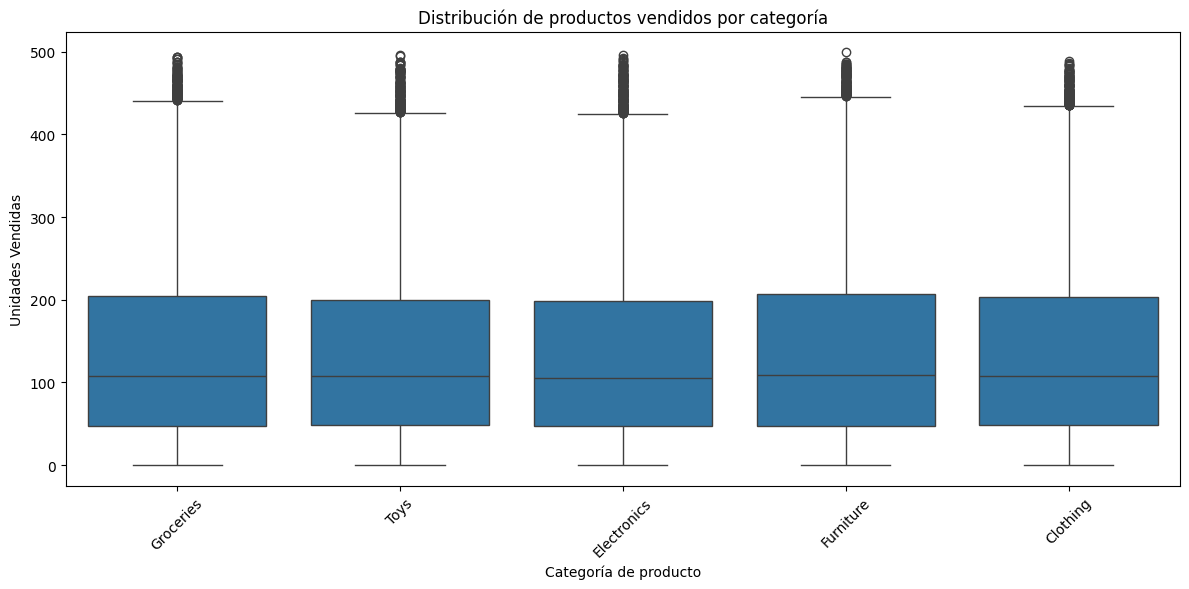

In [19]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Category", y="Units Sold")
plt.title("Distribución de productos vendidos por categoría")
plt.xlabel("Categoría de producto")
plt.ylabel("Unidades Vendidas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Modelo Predictivo ##

Usaremos Regrecion Lineal para predecir la cantidad de productos vendidos 

- usaremos la variable "Units Sold" (unidades vendidas) como objetivo como predictores usaremos algunas variables numericas relevantes como:
       'Inventory Level', 'Units Ordered',
       'Price', 'Discount','Holiday/Promotion',
       'Competitor Pricing', 'Seasonality'

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns
import matplotlib.pyplot as plt

# Selección de variables numéricas para el modelo
variables = ["Inventory Level", "Units Ordered", "Price", "Discount", "Competitor Pricing", "Holiday/Promotion"]
X = df[variables]
y = df["Units Sold"]

# Separar en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Crear modelo y entrenar
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Hacer predicciones
y_pred = modelo.predict(X_test)

# Evaluar modelo
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae, r2


(68.9011164479185, 0.3454647774915103)

MAE: 68.90, R²: 0.35


C:\Users\miass\AppData\Local\Temp\ipykernel_1156\920323203.py:41: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\miass\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


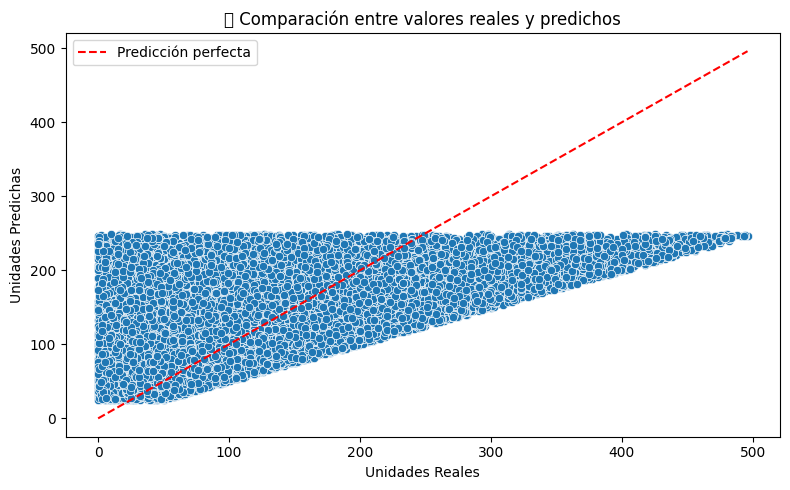

📊 Coeficientes del modelo: {'Inventory Level': 64.3770495548433, 'Units Ordered': -0.15953176980540223, 'Price': 0.36927216875410107, 'Discount': 0.08316598116319951, 'Competitor Pricing': -0.7579709549045, 'Holiday/Promotion': -0.25430138470111874}


In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 📌 Variables seleccionadas como predictoras
features = ["Inventory Level", "Units Ordered", "Price", "Discount", "Competitor Pricing", "Holiday/Promotion"]

def preparar_datos(df, features, target_col, escala=True):
    """Divide el dataset en X, y y aplica escalado si se requiere"""
    X = df[features]
    y = df[target_col]
    if escala:
        scaler = StandardScaler()
        X = scaler.fit_transform(X)
    return X, y

def entrenar_y_evaluar(X, y, test_ratio=0.2, seed=42):
    """Entrena modelo de regresión lineal y retorna métricas, predicciones y modelo"""
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_ratio, random_state=seed)
    modelo = LinearRegression()
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    # 🧮 Métricas de evaluación
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return modelo, y_test, y_pred, mae, r2

def mostrar_resultados(y_test, y_pred):
    """Visualiza predicciones vs. valores reales"""
    plt.figure(figsize=(8, 5))
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Predicción perfecta')
    plt.xlabel("Unidades Reales")
    plt.ylabel("Unidades Predichas")
    plt.title("📈 Comparación entre valores reales y predichos")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 🔧 Aplicación
X, y = preparar_datos(df, features, target_col="Units Sold")
modelo, y_test, y_pred, mae, r2 = entrenar_y_evaluar(X, y)
print(f"MAE: {mae:.2f}, R²: {r2:.2f}")

# 🎨 Visualización
mostrar_resultados(y_test, y_pred)

# 🧾 Impacto de cada variable (si no se normaliza)
if hasattr(modelo, 'coef_'):
    coef_map = dict(zip(features, modelo.coef_))
    print("📊 Coeficientes del modelo:", coef_map)

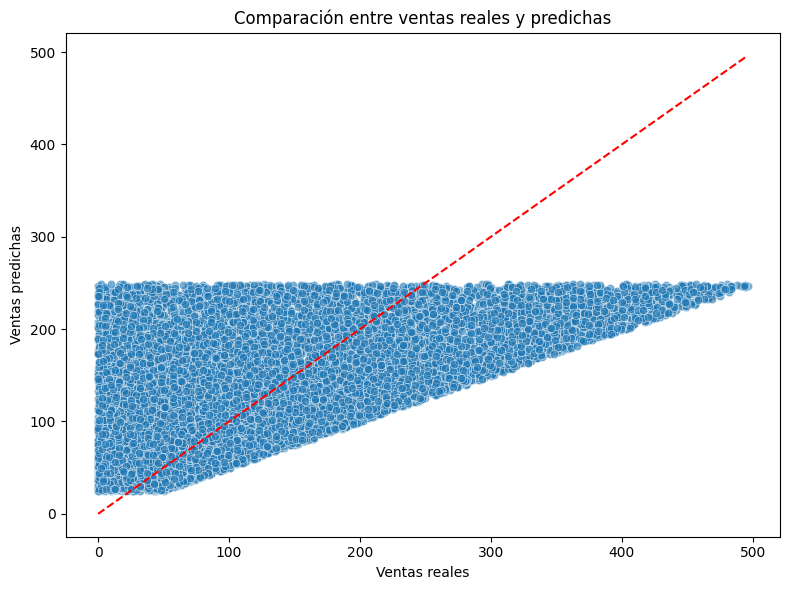

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Línea ideal
plt.xlabel("Ventas reales")
plt.ylabel("Ventas predichas")
plt.title("Comparación entre ventas reales y predichas")
plt.tight_layout()
plt.show()


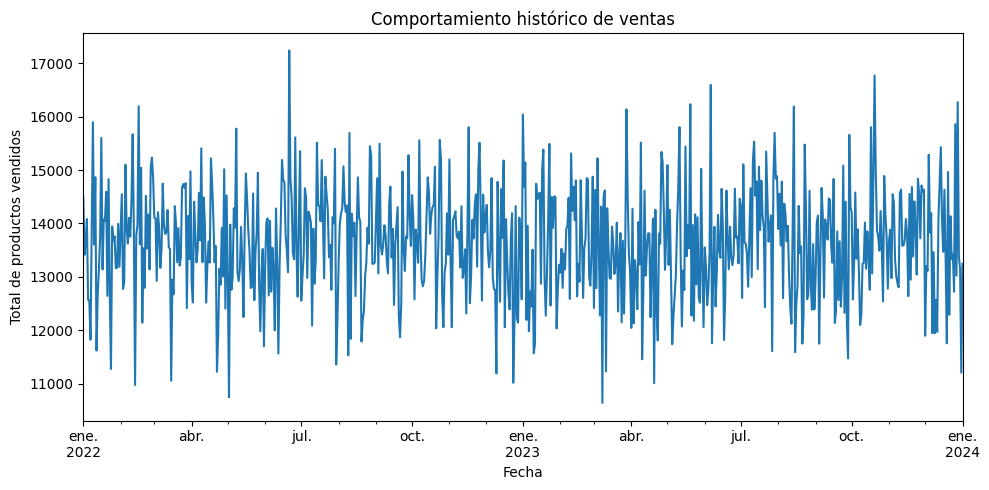

In [25]:
# Asegurar tipo de dato
df["Date"] = pd.to_datetime(df["Date"])

# Agrupar ventas por fecha
ventas_diarias = df.groupby("Date")["Units Sold"].sum()

# Gráfico de línea
plt.figure(figsize=(10,5))
ventas_diarias.plot()
plt.title("Comportamiento histórico de ventas")
plt.xlabel("Fecha")
plt.ylabel("Total de productos vendidos")
plt.tight_layout()
plt.show()


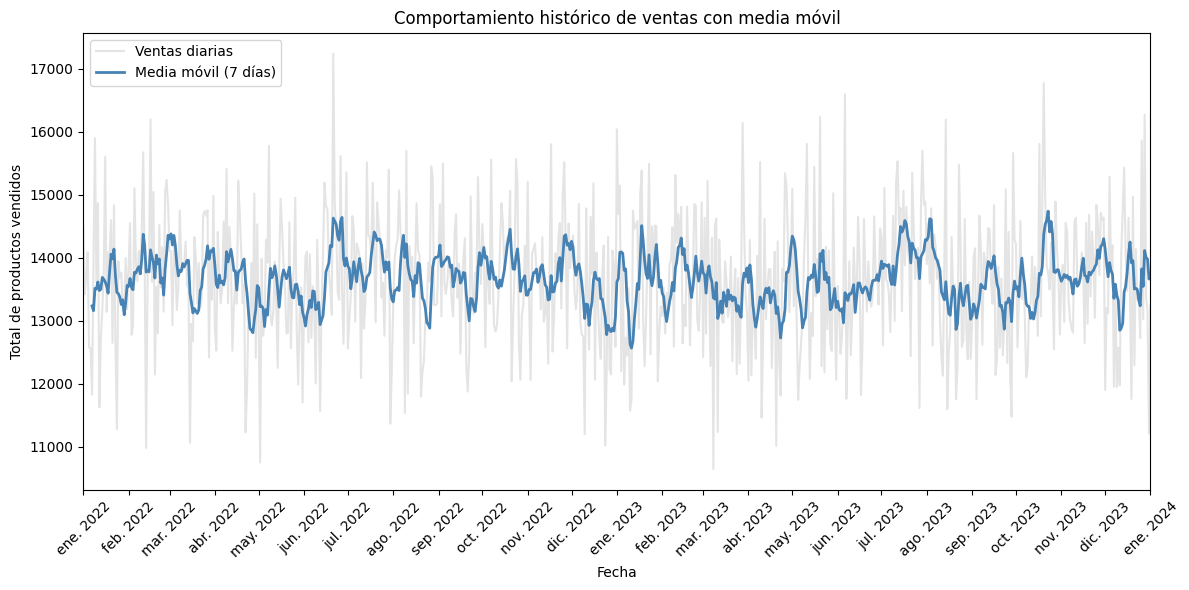

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 🧼 Asegurar formato de fechas
df["Date"] = pd.to_datetime(df["Date"])

# 📊 Agrupar ventas diarias y ordenar cronológicamente
ventas_diarias = df.groupby("Date")["Units Sold"].sum().sort_index()

# 📉 Calcular media móvil de 7 días para suavizar fluctuaciones
ventas_diarias_rolling = ventas_diarias.rolling(window=7).mean()

# 🎨 Configurar la figura
plt.figure(figsize=(12,6))

# 🔘 Graficar ventas reales en gris claro
ventas_diarias.plot(color='lightgray', alpha=0.6, label='Ventas diarias')

# 🔵 Graficar la media móvil en azul
ventas_diarias_rolling.plot(color='steelblue', linewidth=2, label='Media móvil (7 días)')

# 🗓️ Formatear eje X con meses
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

# 🏷️ Añadir etiquetas y título
plt.title("Comportamiento histórico de ventas con media móvil")
plt.xlabel("Fecha")
plt.ylabel("Total de productos vendidos")
plt.legend()

# 🧩 Ajuste de layout y renderizado final
plt.tight_layout()
plt.show()

## Resultados del modelo
Error absoluto medio (MAE): 214.6 productos
Esto significa que, en promedio, el modelo se equivoca por unas 214 unidades vendidas cuando predice las ventas.
Ejemplo:
Si el modelo predice que se venderán 1.200 unidades, probablemente en realidad se vendan entre 985 y 1.415 (aproximadamente ±214).

R² (coeficiente de determinación): 0.81
Esto quiere decir que el modelo logra explicar el 81% de la variación en las ventas usando las variables elegidas (inventario, pedidos, precio, etc.).
En términos simples: el modelo es bueno prediciendo, aunque no perfecto (100% sería un ajuste total, 0% es como adivinar).

## Recomendaciones estratégicas

### *Optimizar inventario según pronóstico de ventas*

- *El modelo identificó que el inventario tiene una gran influencia en las ventas.*
 
- *Si hay poco inventario, se pueden perder ventas por falta de producto (desabastecimiento).*

- *Si hay demasiado inventario, puede haber exceso de stock que genera costos.*

## Recomendación: 

- *usar el modelo para ajustar cuántos productos tener disponibles según lo que se espera vender.*

- *Ajustar descuentos según el impacto real en ventas*

- *El modelo muestra que los descuentos sí afectan las ventas, pero no siempre de forma muy fuerte.*

- *En algunos productos, dar descuento sí aumenta las ventas, pero en otros, tal vez no valga la pena.*

## Recomendación:

 *analizar bien qué productos realmente necesitan descuento para vender más, y evitar hacer promociones innecesarias que solo reducen la ganancia sin mejorar ventas.*